# Fraud Detection — EDA, Feature Engineering & Modeling

Pipeline: EDA → feature engineering → multicollinearity fix (VIF + PCA) → correlation matrix → Mutual Information feature selection (incl. `type`) → train/test split → undersampling → regularized models (LR, Bayesian LR, Decision Tree, Random Forest, XGBoost) → model comparison → confusion matrices → false positive/false negative analysis → feature importance → rule-based flagging engine (business layer).

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score, precision_recall_curve
)

# imbalanced-learn: pip install imbalanced-learn
from imblearn.under_sampling import RandomUnderSampler

# Bayesian LR: pip install pymc arviz
import pymc as pm

SEED = 42
np.random.seed(SEED)

g++ not available, if using conda: `conda install gxx`


In [2]:
import sys
print(sys.executable)

C:\Users\Admin\anaconda3\python.exe


## 2. Load Data

In [3]:
df = pd.read_csv("Synthetic_Financial_Datasets_For_Fraud_Detection_resample.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,182,CASH_IN,100328.70,C197678862,3389602.37,3489931.07,C386191921,219735.14,119406.44,0,0
1,210,PAYMENT,11660.99,C2009511954,94054.00,82393.01,M564284134,0.00,0.00,0,0
2,403,CASH_IN,230751.30,C1132312861,23117012.10,23347763.39,C1025694734,951294.81,720543.51,0,0
3,328,PAYMENT,17833.60,C1191709365,0.00,0.00,M293024801,0.00,0.00,0,0
4,563,CASH_OUT,246476.67,C342438889,0.00,0.00,C2087488957,4226850.16,4473326.82,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636262 entries, 0 to 636261
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            636262 non-null  int64  
 1   type            636262 non-null  object 
 2   amount          636262 non-null  float64
 3   nameOrig        636262 non-null  object 
 4   oldbalanceOrg   636262 non-null  float64
 5   newbalanceOrig  636262 non-null  float64
 6   nameDest        636262 non-null  object 
 7   oldbalanceDest  636262 non-null  float64
 8   newbalanceDest  636262 non-null  float64
 9   isFraud         636262 non-null  int64  
 10  isFlaggedFraud  636262 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 53.4+ MB


In [5]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,636262.000000,6.362620e+05,6.362620e+05,6.362620e+05,6.362620e+05,6.362620e+05,636262.000000,636262.000000
mean,243.603050,1.801858e+05,8.356350e+05,8.566696e+05,1.105524e+06,1.230272e+06,0.001334,0.000003
std,142.142473,6.136135e+05,2.893755e+06,2.929387e+06,3.447599e+06,3.724619e+06,0.036504,0.001773
min,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,156.000000,1.342490e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
50%,239.000000,7.460482e+04,1.423100e+04,0.000000e+00,1.336986e+05,2.154826e+05,0.000000,0.000000
75%,334.000000,2.081028e+05,1.075470e+05,1.446871e+05,9.486479e+05,1.117370e+06,0.000000,0.000000
max,743.000000,7.382349e+07,5.039905e+07,4.367380e+07,3.551855e+08,3.553805e+08,1.000000,1.000000


## 3. Data Quality Check

In [6]:
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nUnique nameOrig:", df['nameOrig'].nunique(), "/", len(df))
print("Unique nameDest:", df['nameDest'].nunique(), "/", len(df))

Missing values per column:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Duplicate rows: 0

Unique nameOrig: 636167 / 636262
Unique nameDest: 457405 / 636262


## 4. EDA

### Class Imbalance: `isFraud`

isFraud
0    635413
1       849
Name: count, dtype: int64
isFraud
0    99.866564
1     0.133436
Name: proportion, dtype: float64


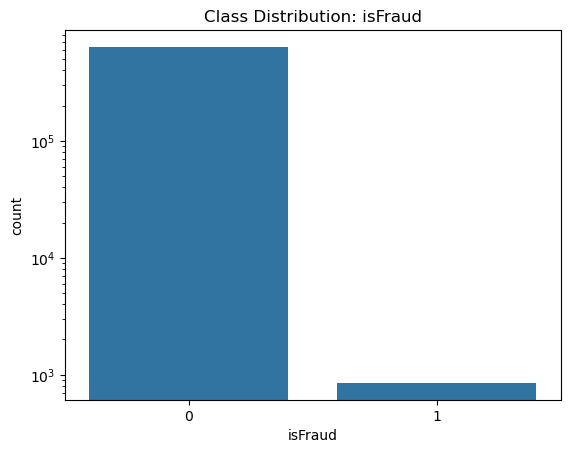

In [7]:
fraud_counts = df['isFraud'].value_counts()
fraud_pct = df['isFraud'].value_counts(normalize=True) * 100
print(fraud_counts)
print(fraud_pct)

sns.countplot(data=df, x='isFraud')
plt.title('Class Distribution: isFraud')
plt.yscale('log')  # log scale since fraud is so rare
plt.show()

### `isFlaggedFraud` vs `isFraud`

**Finding:** `isFlaggedFraud` only catches 2 of 849 actual frauds — not usable as a feature or standalone rule.

In [8]:
pd.crosstab(df['isFraud'], df['isFlaggedFraud'], margins=True)

isFlaggedFraud,0,1,All
isFraud,,,
0,635413,0,635413
1,847,2,849
All,636260,2,636262


### Transaction Type Distribution

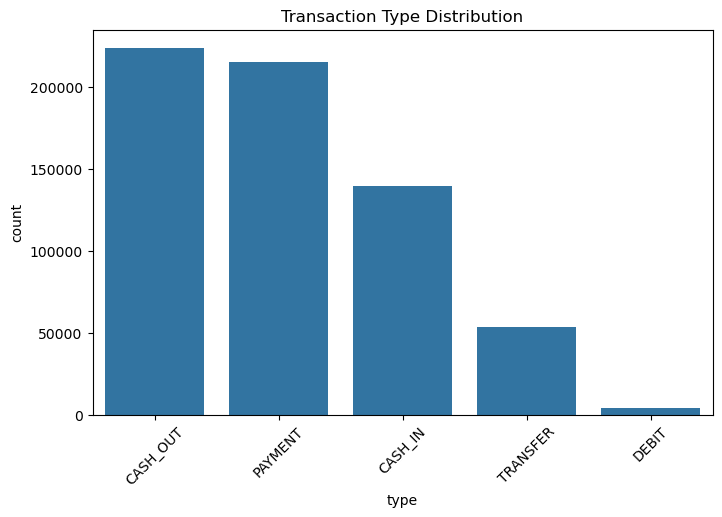

type
CASH_OUT    35.181419
PAYMENT     33.840619
CASH_IN     21.953849
TRANSFER     8.372337
DEBIT        0.651776
Name: proportion, dtype: float64

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='type', order=df['type'].value_counts().index)
plt.title('Transaction Type Distribution')
plt.xticks(rotation=45)
plt.show()

df['type'].value_counts(normalize=True) * 100

### Fraud Rate by Transaction Type

**Finding:** fraud only occurs in `TRANSFER` and `CASH_OUT`. `CASH_IN`, `DEBIT`, and `PAYMENT` have zero fraud cases.

          fraud_count  total_count  fraud_rate
type                                          
TRANSFER          432        53270    0.008110
CASH_OUT          417       223846    0.001863
CASH_IN             0       139684    0.000000
DEBIT               0         4147    0.000000
PAYMENT             0       215315    0.000000


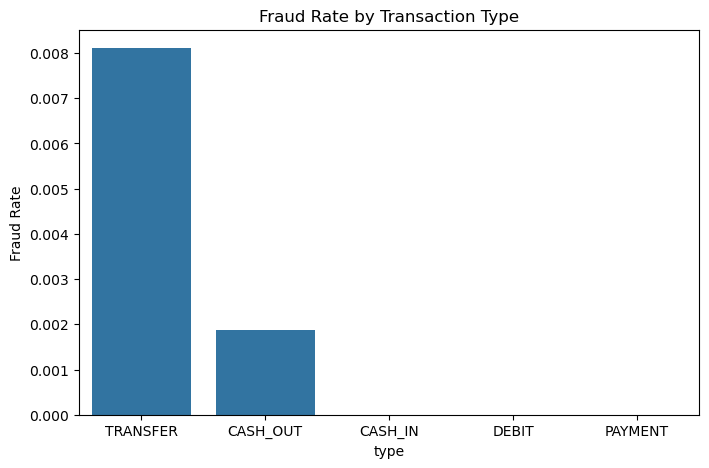

In [10]:
fraud_by_type = df.groupby('type')['isFraud'].agg(['sum', 'count', 'mean']).sort_values('mean', ascending=False)
fraud_by_type.columns = ['fraud_count', 'total_count', 'fraud_rate']
print(fraud_by_type)

plt.figure(figsize=(8,5))
sns.barplot(x=fraud_by_type.index, y=fraud_by_type['fraud_rate'])
plt.title('Fraud Rate by Transaction Type')
plt.ylabel('Fraud Rate')
plt.show()

### Amount Distribution

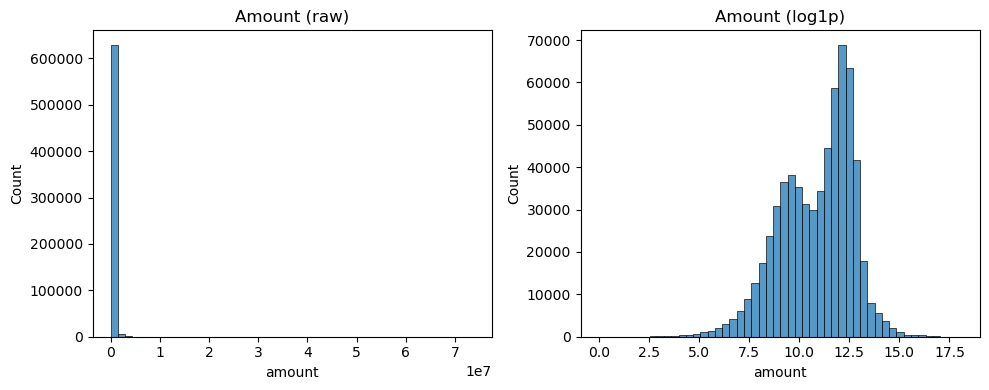

In [11]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df['amount'], bins=50)
plt.title('Amount (raw)')

plt.subplot(1,2,2)
sns.histplot(np.log1p(df['amount']), bins=50)
plt.title('Amount (log1p)')
plt.tight_layout()
plt.show()

### Amount: Fraud vs Non-Fraud

**Finding:** fraud amounts are much larger on average (mean ~$1.5M vs ~$178K for legit).

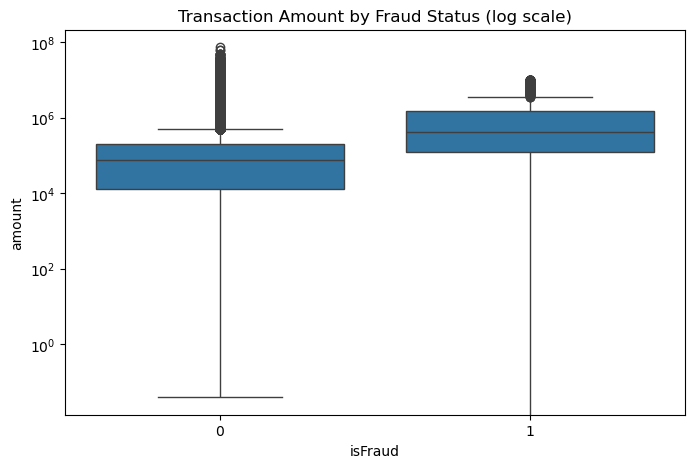

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,635413.0,1.784231e+05,6.053555e+05,0.04,13401.98,74407.10,207725.69,73823490.36
1,849.0,1.499441e+06,2.484921e+06,0.00,126715.84,429257.45,1467987.57,10000000.00


In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='isFraud', y='amount')
plt.yscale('log')
plt.title('Transaction Amount by Fraud Status (log scale)')
plt.show()

df.groupby('isFraud')['amount'].describe()

## 5. Feature Engineering

### Balance-Error Features

**Finding:** fraud's `errorBalanceOrig` median is exactly 0 (arithmetic holds perfectly), while legitimate transactions frequently have nonzero error terms. This is a strong but suspiciously clean synthetic-data artifact — worth treating with caution for generalization.

In [13]:
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

df.groupby('isFraud')[['errorBalanceOrig', 'errorBalanceDest']].describe()

errorBalanceOrig                                               \
                   count           mean            std   min      25%   
isFraud                                                                 
0               635413.0  201475.596602  615933.127941 -0.01  3010.63   
1                  849.0   10199.039505  209592.463532  0.00     0.00   

                                          errorBalanceDest                 \
              50%        75%          max            count           mean   
isFraud                                                                     
0        68591.08  249421.06  73823490.36         635413.0   54466.905994   
1            0.00       0.00   4953893.08            849.0  782614.432450   

                                                                           
                  std          min  25%       50%        75%          max  
isFraud                                                                    
0        4.418107e+05 -61568044.57  0.0   3490.20   29289.25   5353303.68  
1        1.973993e+06   -837588.79  0.0  11070.29  488243.65  10000000.00

### Zero-Balance Flags

**Note:** the origin-side flag means the *opposite* of what might be assumed — only 0.24% of fraud starts from a zero-balance account (you can't drain an empty account). The destination-side flag is a real, if moderate, signal: fraud sends to zero-balance ('mule') accounts more often than legit transactions do.

In [14]:
df['origZeroBefore'] = (df['oldbalanceOrg'] == 0).astype(int)
df['destZeroBefore'] = (df['oldbalanceDest'] == 0).astype(int)
df['destZeroAfter'] = (df['newbalanceDest'] == 0).astype(int)

print("origZeroBefore:")
print(pd.crosstab(df['isFraud'], df['origZeroBefore'], normalize='index'))
print("\ndestZeroBefore:")
print(pd.crosstab(df['isFraud'], df['destZeroBefore'], normalize='index'))
print("\ndestZeroAfter:")
print(pd.crosstab(df['isFraud'], df['destZeroAfter'], normalize='index'))

origZeroBefore:
origZeroBefore         0         1
isFraud                           
0               0.669486  0.330514
1               0.997644  0.002356

destZeroBefore:
destZeroBefore         0         1
isFraud                           
0               0.575352  0.424648
1               0.338045  0.661955

destZeroAfter:
destZeroAfter         0         1
isFraud                          
0              0.616726  0.383274
1              0.491166  0.508834


### Snapshot for the Rule-Based Flagging Engine

The PCA step below collapses `amount` and `errorBalanceOrig` into a single component and drops the originals. The rule-based engine (Section 14) needs the raw, human-readable columns, so we keep an untouched copy here before that happens.

In [15]:
df_raw = df.copy()

### Time Features

`step` = 1 simulated hour (1–743, ≈31 days). We derive hour-of-day and day for cleaner patterns.

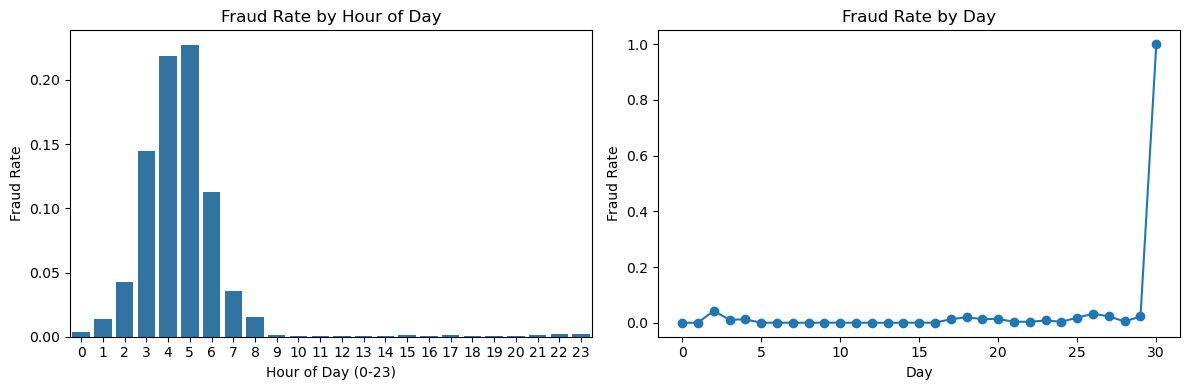

In [16]:
df['hour_of_day'] = df['step'] % 24
df['day'] = df['step'] // 24

hourly_fraud = df.groupby('hour_of_day')['isFraud'].agg(['sum', 'count', 'mean'])
hourly_fraud.columns = ['fraud_count', 'total_count', 'fraud_rate']

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.barplot(x=hourly_fraud.index, y=hourly_fraud['fraud_rate'])
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Fraud Rate')

plt.subplot(1,2,2)
daily_fraud = df.groupby('day')['isFraud'].mean()
daily_fraud.plot(marker='o')
plt.title('Fraud Rate by Day')
plt.xlabel('Day')
plt.ylabel('Fraud Rate')
plt.tight_layout()
plt.show()

### EDA Summary

- Severe class imbalance: 0.13% fraud (849 / 636,262)
- `isFlaggedFraud` catches only 2 of 849 frauds — not usable
- Fraud is 100% confined to `TRANSFER` and `CASH_OUT`
- Strongest features found: `errorBalanceOrig`/`errorBalanceDest`, `destZeroBefore`
- Dropped: ID columns (`nameOrig`/`nameDest`), `isFlaggedFraud` (not predictive), `origZeroBefore`-based interactions (misleading — origin accounts are rarely empty *before* fraud, only *after*)

## 6. Multicollinearity Check (before fix)

In [17]:
vif_cols = [
    'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
]

X = add_constant(df[vif_cols].dropna())
vif_before = pd.DataFrame({
    'feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
}).query("feature != 'const'").sort_values('VIF', ascending=False)

print(vif_before)

          feature         VIF
3  newbalanceOrig  409.963189
2   oldbalanceOrg  409.098398
5  newbalanceDest   74.436751
4  oldbalanceDest   64.606767
1          amount    3.718825


**Finding:** `oldbalanceOrg`/`newbalanceOrig` and `oldbalanceDest`/`newbalanceDest` are each near-duplicate pairs (VIF far above 10). `amount` and `errorBalanceOrig` are also highly correlated (r ≈ 0.97) since `amount` is a term inside `errorBalanceOrig`'s formula. We resolve the origin/destination raw-balance redundancy by keeping only the `new*` balance (drop the `old*` balance, since the error features already encode the difference), and resolve `amount` vs `errorBalanceOrig` with PCA below.

### PCA: `amount` + `errorBalanceOrig` → 1 component

In [18]:
pca_features = ['amount', 'errorBalanceOrig']
X_scaled_pca = StandardScaler().fit_transform(df[pca_features])

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled_pca)
print("Explained variance ratio:", pca.explained_variance_ratio_)
# PC1 explains ~98.5% of the shared variance -> safe to collapse to 1 component

df['amount_errBal_PC1'] = pca_result[:, 0]
df = df.drop(columns=['amount', 'errorBalanceOrig'])

Explained variance ratio: [0.98508473 0.01491527]


### Final Feature Set + VIF Confirmation

In [19]:
final_features = [
    'amount_errBal_PC1',   # replaces amount + errorBalanceOrig
    'newbalanceOrig',      # dropped oldbalanceOrg (near-duplicate)
    'newbalanceDest',      # dropped oldbalanceDest (near-duplicate)
    'errorBalanceDest',
    'origZeroBefore', 'destZeroBefore', 'destZeroAfter',
    'hour_of_day', 'day'
]

X_check = add_constant(df[final_features].dropna())
vif_final = pd.DataFrame({
    'feature': X_check.columns,
    'VIF': [variance_inflation_factor(X_check.values, i) for i in range(X_check.shape[1])]
}).query("feature != 'const'").sort_values('VIF', ascending=False)

print(vif_final)  # all should be well under 5

             feature       VIF
6     destZeroBefore  3.550029
7      destZeroAfter  3.423594
3     newbalanceDest  1.363468
1  amount_errBal_PC1  1.296755
2     newbalanceOrig  1.135138
4   errorBalanceDest  1.097621
5     origZeroBefore  1.082963
9                day  1.004151
8        hour_of_day  1.001874


### Correlation Matrix — Final Feature Set

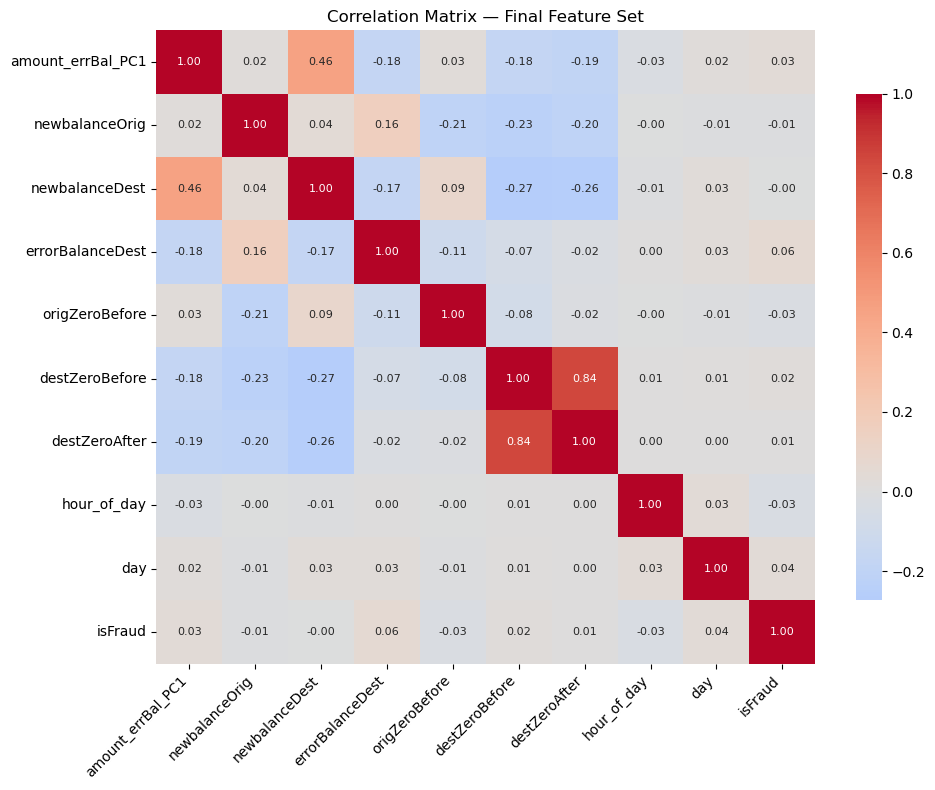

In [20]:
corr_cols = final_features + ['isFraud']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            annot_kws={'size': 8}, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Final Feature Set')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Note:** every feature has weak *linear* correlation with `isFraud` — expected, since fraud here follows threshold/interaction rules (e.g. `errorBalanceOrig` == 0 AND `type` == TRANSFER) rather than linear relationships. This is exactly the kind of pattern tree-based models are built to capture, and correlation alone will underestimate their usefulness.

## 7. Mutual Information Feature Selection

Correlation only captures linear relationships, which is why every feature above looked weak against `isFraud` despite some being highly predictive in practice (e.g. `errorBalanceOrig` == 0). **Mutual Information (MI)** captures nonlinear and threshold-based relationships too, so it's a better screen for this dataset.

This also fixes a gap from the VIF/PCA-only feature set: `type` was never included, even though fraud is 100% confined to `TRANSFER`/`CASH_OUT` — one of the strongest signals in the whole dataset. We one-hot encode it here and let MI confirm how strong it actually is relative to everything else.

In [21]:
# One-hot encode `type` (fixes a gap in the earlier VIF/PCA-only feature set)
type_dummies = pd.get_dummies(df['type'], prefix='type', drop_first=True).astype(int)
df = pd.concat([df, type_dummies], axis=1)

mi_candidate_features = (
    final_features + type_dummies.columns.tolist()
)
mi_candidate_features = [c for c in mi_candidate_features if c in df.columns]
print(mi_candidate_features)

['amount_errBal_PC1', 'newbalanceOrig', 'newbalanceDest', 'errorBalanceDest', 'origZeroBefore', 'destZeroBefore', 'destZeroAfter', 'hour_of_day', 'day', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


day                  0.001510
errorBalanceDest     0.001450
hour_of_day          0.001398
amount_errBal_PC1    0.000931
type_TRANSFER        0.000819
newbalanceOrig       0.000641
type_PAYMENT         0.000552
origZeroBefore       0.000515
destZeroBefore       0.000152
newbalanceDest       0.000115
type_CASH_OUT        0.000054
destZeroAfter        0.000043
type_DEBIT           0.000009
dtype: float64


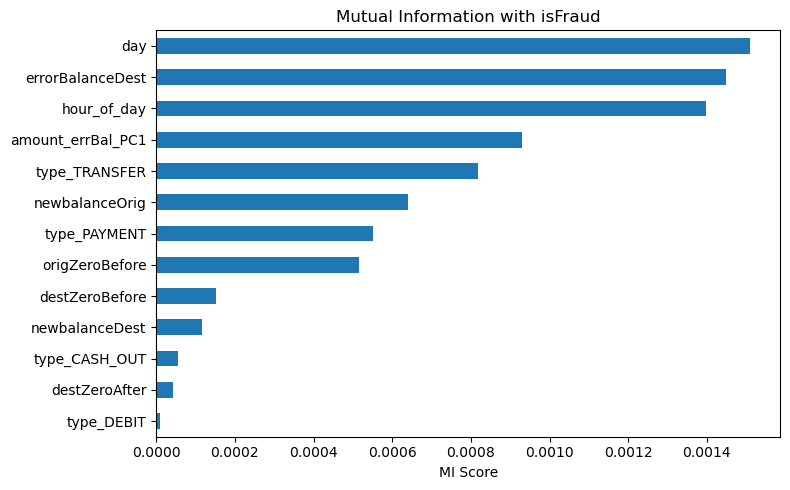

In [22]:
from sklearn.feature_selection import mutual_info_classif

# Mark which candidate features are discrete (binary flags, type dummies, integer time features)
discrete_flags = {'origZeroBefore', 'destZeroBefore', 'destZeroAfter', 'hour_of_day', 'day'}
discrete_mask = [
    (col in discrete_flags) or col.startswith('type_')
    for col in mi_candidate_features
]

mi_scores = mutual_info_classif(
    df[mi_candidate_features], df['isFraud'],
    discrete_features=discrete_mask, random_state=SEED
)

mi_ranked = pd.Series(mi_scores, index=mi_candidate_features).sort_values(ascending=False)
print(mi_ranked)

plt.figure(figsize=(8,5))
mi_ranked.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Mutual Information with isFraud')
plt.xlabel('MI Score')
plt.tight_layout()
plt.show()

### Selecting the MI Feature Set

Keep the top features by MI score — this is the feature set used for training from here on, replacing the earlier VIF/PCA-only `final_features`.

In [23]:
TOP_N = 8
mi_features = mi_ranked.head(TOP_N).index.tolist()
print("Selected MI features:", mi_features)

Selected MI features: ['day', 'errorBalanceDest', 'hour_of_day', 'amount_errBal_PC1', 'type_TRANSFER', 'newbalanceOrig', 'type_PAYMENT', 'origZeroBefore']


## 8. Train/Test Split + Undersampling

Split first, then undersample **only the training set** — undersampling before the split would leak information into the test set and inflate apparent performance.

In [24]:
X = df[mi_features]
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print("Train fraud rate:", y_train.mean())
print("Test fraud rate:", y_test.mean())

# Undersample majority class in training data only (fraud:legit = 1:2)
rus = RandomUnderSampler(random_state=SEED, sampling_strategy=0.5)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print("Before undersampling:", y_train.value_counts().to_dict())
print("After undersampling:", y_train_rus.value_counts().to_dict())

Train fraud rate: 0.001333964625379905
Test fraud rate: 0.0013359213535240819
Before undersampling: {0: 508330, 1: 679}
After undersampling: {0: 1358, 1: 679}


### Feature Scaling (for LR and Bayesian LR)

Tree-based models don't need scaling, but LR and the ADVI-based Bayesian LR are sensitive to feature magnitude — unscaled inputs (e.g. balances in the millions vs. 0/1 flags) distort the regularization and gradient behavior.

In [25]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_rus), columns=mi_features, index=X_train_rus.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=mi_features, index=X_test.index
)

## 9. Model Training

Regularization notes:
- **LR**: `LogisticRegressionCV` searches for the best L2 strength (`C`) via cross-validation, on scaled data.
- **DT / RF / XGBoost**: depth/leaf constraints act as regularization for trees — this also curbs overfitting to the near-deterministic `errorBalanceOrig`/`amount` artifact found in EDA.
- **Bayesian LR**: the prior width is the regularization — a tighter prior (`sigma=1`) on scaled inputs is a stronger, more stable penalty than a wide prior on raw-scale inputs.

In [26]:
models = {
    'LR': LogisticRegressionCV(
        Cs=10, cv=5, max_iter=1000, scoring='average_precision', random_state=SEED
    ),
    'DT': DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, random_state=SEED),
    'RF': RandomForestClassifier(
        max_depth=8, min_samples_leaf=10, n_jobs=-1, random_state=SEED
    ),
    'XGBoost': XGBClassifier(
        max_depth=4, reg_lambda=1.0, reg_alpha=0.1,
        random_state=SEED, eval_metric='logloss'
    ),
}

results = {}

for name, model in models.items():
    print(f"\n{'='*50}\n{name}\n{'='*50}")

    if name == 'LR':
        model.fit(X_train_scaled, y_train_rus)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train_rus, y_train_rus)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    print(classification_report(y_test, y_pred, digits=4))

    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC:  {pr_auc:.4f}")

    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_proba': y_proba,
        'roc_auc': roc_auc, 'pr_auc': pr_auc
    }

print("\nBest C for LR:", models['LR'].C_)


LR
              precision    recall  f1-score   support

           0     0.9997    0.9242    0.9604    127083
           1     0.0135    0.7765    0.0266       170

    accuracy                         0.9240    127253
   macro avg     0.5066    0.8503    0.4935    127253
weighted avg     0.9984    0.9240    0.9592    127253

ROC-AUC: 0.9432
PR-AUC:  0.0746

DT
              precision    recall  f1-score   support

           0     0.9998    0.9824    0.9910    127083
           1     0.0614    0.8588    0.1146       170

    accuracy                         0.9823    127253
   macro avg     0.5306    0.9206    0.5528    127253
weighted avg     0.9986    0.9823    0.9899    127253

ROC-AUC: 0.9733
PR-AUC:  0.1684

RF
              precision    recall  f1-score   support

           0     0.9998    0.9820    0.9908    127083
           1     0.0607    0.8706    0.1135       170

    accuracy                         0.9818    127253
   macro avg     0.5303    0.9263    0.5522    12725

### Bayesian Logistic Regression (PyMC, ADVI)

In [27]:
X_train_arr = X_train_scaled.values
y_train_arr = y_train_rus.values
X_test_arr = X_test_scaled.values
n_features = X_train_arr.shape[1]

with pm.Model() as blr_model:
    intercept = pm.Normal('intercept', mu=0, sigma=1)
    coefs = pm.Normal('coefs', mu=0, sigma=1, shape=n_features)

    logits = intercept + pm.math.dot(X_train_arr, coefs)
    p = pm.Deterministic('p', pm.math.sigmoid(logits))

    y_obs = pm.Bernoulli('y_obs', p=p, observed=y_train_arr)

    approx = pm.fit(n=20000, method='advi', random_seed=SEED)
    trace = approx.sample(1000)

intercept_mean = trace.posterior['intercept'].mean().item()
coefs_mean = trace.posterior['coefs'].mean(dim=['chain', 'draw']).values

logits_test = intercept_mean + X_test_arr @ coefs_mean
y_proba_blr = 1 / (1 + np.exp(-logits_test))
y_pred_blr = (y_proba_blr >= 0.5).astype(int)

results['BLR'] = {
    'model': None,
    'y_pred': y_pred_blr,
    'y_proba': y_proba_blr,
    'roc_auc': roc_auc_score(y_test, y_proba_blr),
    'pr_auc': average_precision_score(y_test, y_proba_blr)
}

print(classification_report(y_test, y_pred_blr, digits=4))
print(f"ROC-AUC: {results['BLR']['roc_auc']:.4f}")
print(f"PR-AUC:  {results['BLR']['pr_auc']:.4f}")

Output()

Finished [100%]: Average Loss = 587.33


              precision    recall  f1-score   support

           0     0.9997    0.9240    0.9604    127083
           1     0.0135    0.7765    0.0265       170

    accuracy                         0.9238    127253
   macro avg     0.5066    0.8502    0.4934    127253
weighted avg     0.9984    0.9238    0.9591    127253

ROC-AUC: 0.9427
PR-AUC:  0.0754


## 10. Model Comparison

In [28]:
summary_df = pd.DataFrame({
    name: {'ROC-AUC': r['roc_auc'], 'PR-AUC': r['pr_auc']}
    for name, r in results.items()
}).T.sort_values('PR-AUC', ascending=False)
print(summary_df)

          ROC-AUC    PR-AUC
XGBoost  0.990597  0.593628
RF       0.987942  0.570394
DT       0.973349  0.168415
BLR      0.942711  0.075449
LR       0.943211  0.074554


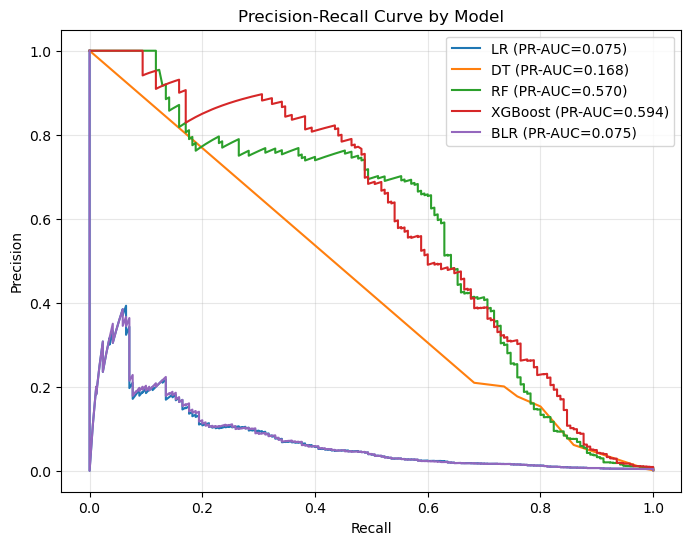

In [29]:
plt.figure(figsize=(8,6))
for name, r in results.items():
    precision, recall, _ = precision_recall_curve(y_test, r['y_proba'])
    plt.plot(recall, precision, label=f"{name} (PR-AUC={r['pr_auc']:.3f})")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve by Model')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 11. Confusion Matrices

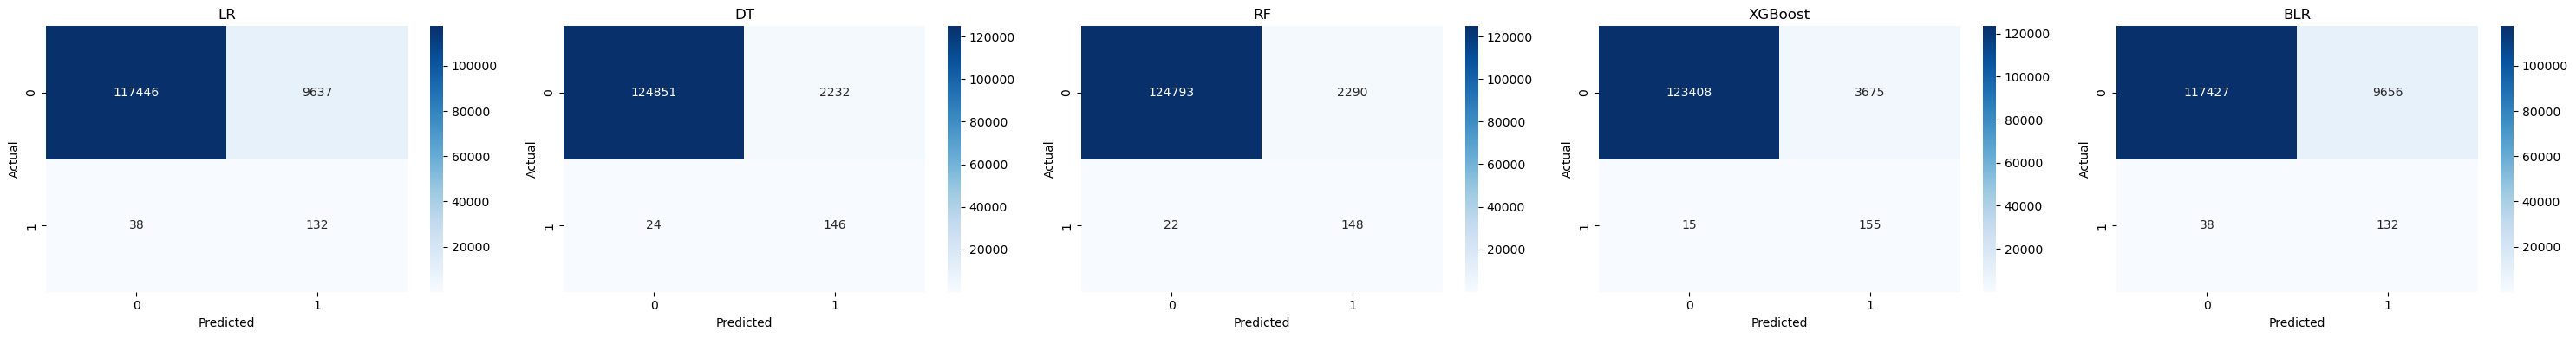

In [30]:
fig, axes = plt.subplots(1, len(results), figsize=(6*len(results), 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

## 12. False Positives vs False Negatives

This is the comparison that matters most for a business decision, more so than ROC-AUC or even PR-AUC alone:
- **False Negatives (FN)** = fraud the model missed entirely — the costly failure mode, since the bank loses the transferred funds.
- **False Positives (FP)** = legitimate transactions flagged as fraud — the friction failure mode, since it blocks/delays real customers and costs investigation time.

Whichever model has the best PR-AUC may still trade off FN and FP very differently, and that tradeoff is exactly what the classification threshold controls — this table is the foundation for the cost-based threshold justification.

In [31]:
error_rows = []
for name, r in results.items():
    tn, fp, fn, tp = confusion_matrix(y_test, r['y_pred']).ravel()
    error_rows.append({
        'model': name,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'FN_rate (missed fraud)': fn / (fn + tp) if (fn + tp) > 0 else np.nan,
        'FP_rate (false alarms)': fp / (fp + tn) if (fp + tn) > 0 else np.nan,
    })

error_df = pd.DataFrame(error_rows).set_index('model').sort_values('FN_rate (missed fraud)')
print(error_df)

             TN    FP  FN   TP  FN_rate (missed fraud)  FP_rate (false alarms)
model                                                                         
XGBoost  123408  3675  15  155                0.088235                0.028918
RF       124793  2290  22  148                0.129412                0.018020
DT       124851  2232  24  146                0.141176                0.017563
LR       117446  9637  38  132                0.223529                0.075832
BLR      117427  9656  38  132                0.223529                0.075982


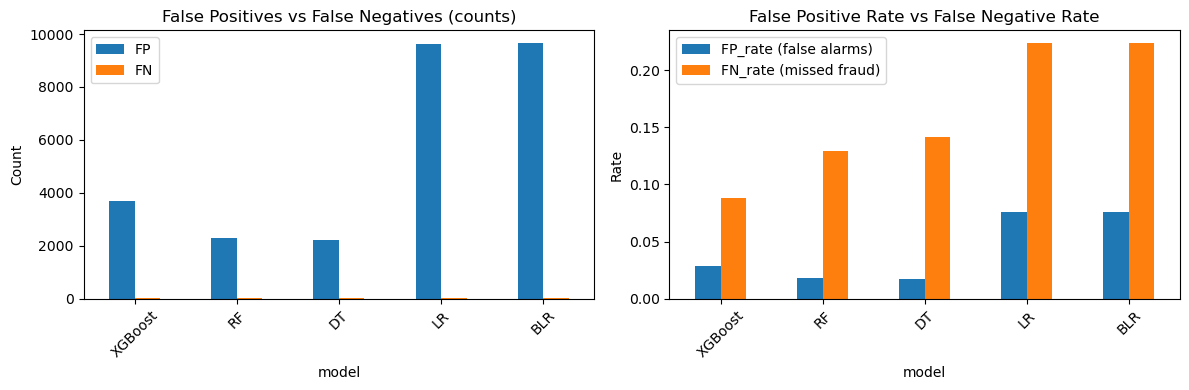

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

error_df[['FP', 'FN']].plot(kind='bar', ax=axes[0])
axes[0].set_title('False Positives vs False Negatives (counts)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

error_df[['FP_rate (false alarms)', 'FN_rate (missed fraud)']].plot(kind='bar', ax=axes[1])
axes[1].set_title('False Positive Rate vs False Negative Rate')
axes[1].set_ylabel('Rate')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Note:** FN rate (miss rate) and FP rate (false alarm rate) are more comparable across models than raw counts, since the test set is heavily imbalanced — a model that flags almost everything as fraud will show a low FN count but a very high FP rate. Look at both columns together, not just one.

## 13. Feature Importance: XGBoost vs RF vs LR vs Mutual Information

Four independent methods, normalized to the same 0-1 scale so they're comparable side by side. Where they agree, that's strong, robust evidence of a real signal (good for business recommendations). Where they disagree, that usually reflects *how* each model type captures signal — e.g. trees pick up threshold/interaction effects that LR structurally cannot represent.

                    XGBoost        RF        LR  Mutual_Info
origZeroBefore     0.347664  0.114028  0.224691     0.065906
newbalanceOrig     0.211969  0.113950  0.127232     0.081990
type_TRANSFER      0.170382  0.153211  0.068846     0.104767
type_PAYMENT       0.103180  0.043487  0.282766     0.070597
errorBalanceDest   0.094104  0.176642  0.132459     0.185502
day                0.030544  0.154112  0.059396     0.193288
hour_of_day        0.029408  0.172516  0.056633     0.178874
amount_errBal_PC1  0.012749  0.072054  0.047976     0.119077


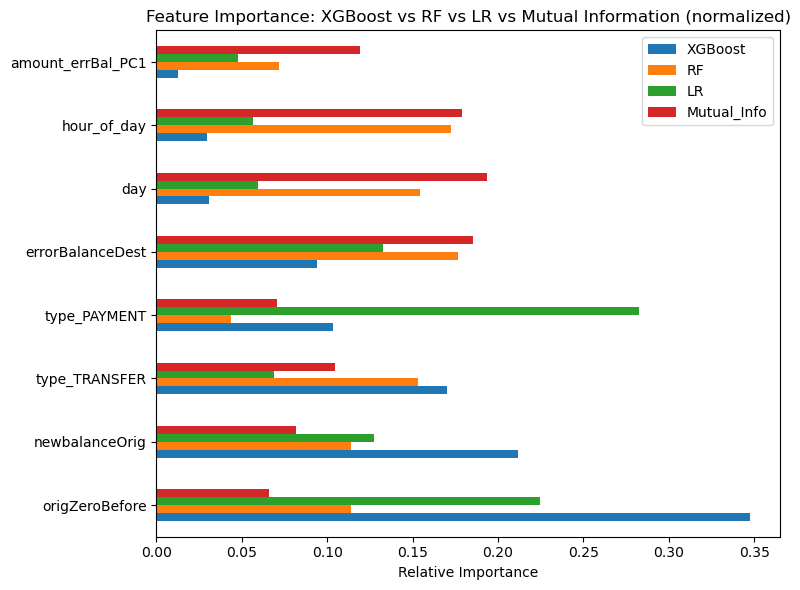

In [33]:
lr_importance = pd.Series(np.abs(models['LR'].coef_[0]), index=mi_features)

importances = pd.DataFrame({
    'XGBoost': results['XGBoost']['model'].feature_importances_,
    'RF': results['RF']['model'].feature_importances_,
    'LR': lr_importance,
    'Mutual_Info': mi_ranked.reindex(mi_features),
}, index=mi_features)

importances_norm = (importances / importances.sum()).sort_values('XGBoost', ascending=False)
print(importances_norm)

importances_norm.plot(kind='barh', figsize=(8,6))
plt.title('Feature Importance: XGBoost vs RF vs LR vs Mutual Information (normalized)')
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

### SHAP Analysis: XGBoost

Feature importance above shows *how much* each feature matters on average, but not the *direction* of its effect or how that effect varies case by case. SHAP (SHapley Additive exPlanations) decomposes each individual prediction into per-feature contributions, so it complements the global importance plot with:

- **Direction**: does a high value of a feature push the prediction toward fraud or away from it?
- **Magnitude**: how large is that push, and does it vary across the range of the feature (e.g. threshold effects)?

Since XGBoost is a tree ensemble, `TreeExplainer` computes exact SHAP values efficiently (no sampling approximation needed).

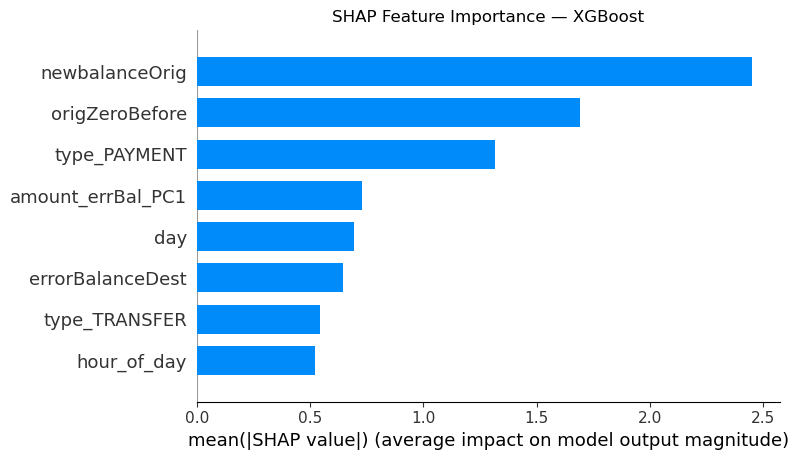

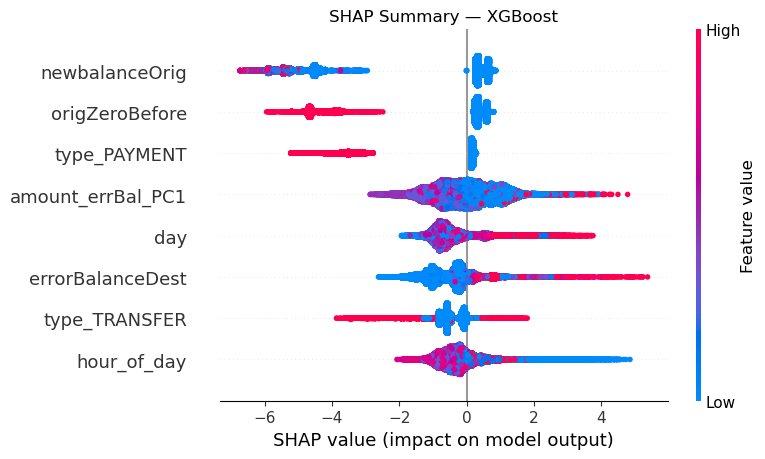

In [34]:
import shap

xgb_model = results['XGBoost']['model']
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Global importance: mean |SHAP value| per feature
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance — XGBoost')
plt.tight_layout()
plt.show()

# Beeswarm: direction + magnitude of each feature's effect across all test rows
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary — XGBoost')
plt.tight_layout()
plt.show()

## 14. Rule-Based Fraud Flagging Engine

A simple, interpretable alternative to the ML models: count how many known fraud-pattern rules a transaction triggers, and flag it once the count crosses a threshold. This is the logic behind the mini website — no trained model required, every flag is explainable in plain language to a fraud analyst.

Uses `df_raw` (saved in Section 5, before PCA collapsed `amount`/`errorBalanceOrig`) since the rules need the original, human-readable columns.

In [35]:
def flag_transaction(row):
    """Rule-based fraud flagging. Returns dict of rule hits + total score."""
    rules = {
        'type_risk': row['type'] in ['TRANSFER', 'CASH_OUT'],
        'error_balance_zero': abs(row['newbalanceOrig'] + row['amount'] - row['oldbalanceOrg']) < 1,
        'origin_drained': (row['oldbalanceOrg'] > 0) and (row['newbalanceOrig'] == 0),
        'dest_zero_before': row['oldbalanceDest'] == 0,
        'dest_zero_after': row['newbalanceDest'] == 0,
        'large_amount': row['amount'] > 200_000,
    }
    rules['rule_count'] = sum(rules.values())
    return rules

rule_results = df_raw.apply(flag_transaction, axis=1, result_type='expand')
df_flagged = pd.concat([df_raw, rule_results], axis=1)

### Threshold Sweep — Evaluated on the Same Test Set as the ML Models

Restricting to `X_test`'s rows keeps this comparison fair — the ML models never saw these rows during training either.

In [36]:
test_idx = X_test.index
rule_test = df_flagged.loc[test_idx]

for threshold in [1, 2, 3, 4]:
    y_pred_rule = (rule_test['rule_count'] >= threshold).astype(int)
    print(f"\n=== Flag if rule_count >= {threshold} ===")
    print(classification_report(y_test, y_pred_rule, digits=4))

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rule).ravel()
    print(f"FP: {fp}  FN: {fn}  FP_rate: {fp/(fp+tn):.4f}  FN_rate: {fn/(fn+tp):.4f}")


=== Flag if rule_count >= 1 ===
              precision    recall  f1-score   support

           0     1.0000    0.1223    0.2179    127083
           1     0.0015    1.0000    0.0030       170

    accuracy                         0.1234    127253
   macro avg     0.5008    0.5611    0.1105    127253
weighted avg     0.9987    0.1234    0.2176    127253

FP: 111546  FN: 0  FP_rate: 0.8777  FN_rate: 0.0000

=== Flag if rule_count >= 2 ===
              precision    recall  f1-score   support

           0     1.0000    0.3096    0.4728    127083
           1     0.0019    1.0000    0.0039       170

    accuracy                         0.3105    127253
   macro avg     0.5010    0.6548    0.2383    127253
weighted avg     0.9987    0.3105    0.4722    127253

FP: 87738  FN: 0  FP_rate: 0.6904  FN_rate: 0.0000

=== Flag if rule_count >= 3 ===
              precision    recall  f1-score   support

           0     1.0000    0.6394    0.7800    127083
           1     0.0037    1.0000  

### Add the Rule Engine to the FP/FN Comparison

Pick the threshold that gave the best balance above and add it alongside the ML models for a direct, apples-to-apples comparison.

In [37]:
RULE_THRESHOLD = 2  # update based on the sweep above

y_pred_rule_final = (rule_test['rule_count'] >= RULE_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rule_final).ravel()

error_df.loc[f'Rules (>={RULE_THRESHOLD})'] = {
    'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
    'FN_rate (missed fraud)': fn / (fn + tp) if (fn + tp) > 0 else np.nan,
    'FP_rate (false alarms)': fp / (fp + tn) if (fp + tn) > 0 else np.nan,
}
print(error_df.sort_values('FN_rate (missed fraud)'))

                 TN     FP  FN   TP  FN_rate (missed fraud)  \
model                                                         
Rules (>=2)   39345  87738   0  170                0.000000   
XGBoost      123408   3675  15  155                0.088235   
RF           124793   2290  22  148                0.129412   
DT           124851   2232  24  146                0.141176   
LR           117446   9637  38  132                0.223529   
BLR          117427   9656  38  132                0.223529   

             FP_rate (false alarms)  
model                                
Rules (>=2)                0.690399  
XGBoost                    0.028918  
RF                         0.018020  
DT                         0.017563  
LR                         0.075832  
BLR                        0.075982  
